In [ ]:
import duckdb
import numpy as np
from functions.full_model import retrain
from functions.full_model import get_predict_fn
from functions.evaluation import evaluate
from networks.cnn_network import CNNModel
from networks.cnn_network import build_dataloaders


con = duckdb.connect('../capillary.db')
df = con.execute(""" 
                 SELECT id, value,fractions, boundaries,albumin,antitrypsin,orosomukoid,haptoglobin,crp,igg,iga,igm, label, set, interpretation
                 FROM protein_data
                 WHERE value IS NOT NULL
                 AND observation_nr = 1
                 AND analysis IS NOT NULL
                 AND protein_value IS NOT NULL
                 """).df()
con.close()

df = df[
    (df['fractions'].apply(len) == 6) &
    (df['boundaries'].apply(len) == 12)
]

df['value'] = df['value'].apply(lambda x: x/ np.max(x))

train_rows = df[df['set'] == 'train']
val_rows   = df[df['set'] == 'val']
test_rows  = df[df['set'] == 'test']

drop_indices = train_rows[train_rows['label'] == 0].sample(frac=0.5).index


train_rows = train_rows.drop(drop_indices)
train_rows = train_rows[train_rows['label'].isin([0,1])]
val_rows = val_rows[val_rows['label'].isin([0,1])]

print(f"Antal utan m-komponent i träningsdatan: {len(train_rows[train_rows['label'] == 0])}")
print(f"Antal med m-komponent i träningsdatan: {len(train_rows[train_rows['label'] == 1])}")

CNN = CNNModel()
cnn_train_dl, cnn_val_dl, _ = build_dataloaders(train_rows, val_rows, val_rows)
#CNN.retrain(cnn_train_dl,cnn_val_dl,model_path='../models/convolution_model_scaled_cnn.pth',patience=15)

Antal utan m-komponent i träningsdatan: 30492
Antal med m-komponent i träningsdatan: 4730


              precision    recall  f1-score   support

     Negativ       0.97      0.95      0.96      7146
     Positiv       0.52      0.70      0.60       586

    accuracy                           0.93      7732
   macro avg       0.75      0.82      0.78      7732
weighted avg       0.94      0.93      0.93      7732

[[6763  383]
 [ 175  411]]
AUC: 0.9013988111442569
Accuracy:  92.78%
FN-rate:   29.86%  (farliga missade fall)
FP-rate:   5.36%  (onödiga larm)
Sensitivitet:   70.14%  (Sannolikhet att upptäcka ett positivt fall)
Specificitet:   94.64%  (Sannolikhet att korrekt klassificera ett negativt fall negativt)
AUC: 0.9014


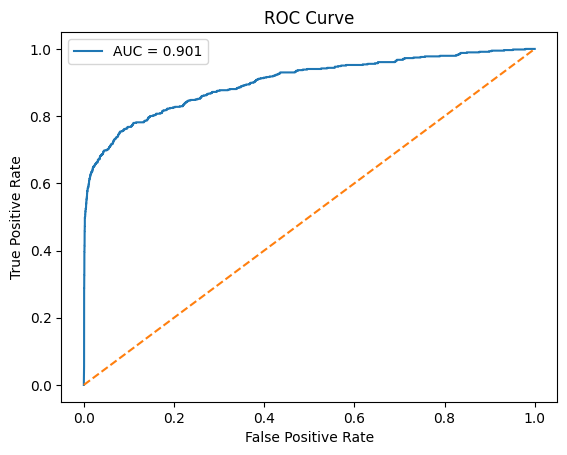

In [2]:
predict_fn = get_predict_fn(cnn_suffix = 'scaled_cnn',ae_suffix='first_time')
test_rows = test_rows[test_rows['label'].isin([0,1])]
result = predict_fn(test_rows)
_ = evaluate(result,threshold=0.5,proportion=70)

In [ ]:
## Slutsats -> sämre resultat om jag skalar datan innan